# Carregando dataframe

## Importação das bibliotecas

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv("../dados/Varejo.csv", sep=';')

## Análise exploratória dos dados

In [46]:
print(f'O dataframe possui {df.shape[0]} linhas e {df.shape[1]} colunas')


O dataframe possui 830000 linhas e 14 colunas


In [47]:
print('\n Início do dataframe: \n')
df.head()


 Início do dataframe: 



,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,01/02/2019,1000,534,M,4,1,C,67,BEBIDAS,REFRIGERANTE GUARANA,NaN,NaN,NaN,NaN
1,01/02/2019,1000,534,M,4,1,C,70,BEBIDAS,REFRIGERANTE OUTROS,NaN,NaN,NaN,NaN
2,01/02/2019,1000,534,M,4,1,C,178,HIGIENE,LENCO UMEDECIDO,NaN,NaN,NaN,NaN
3,01/02/2019,1000,534,M,4,1,C,4,ALIMENTOS,ABACAXI,NaN,NaN,NaN,NaN
4,01/02/2019,1000,534,M,4,1,C,175,LIMPEZA,LIMPADOR MULTIUSO,NaN,NaN,NaN,NaN


In [48]:
print('\n Final do dataframe: \n')
df.tail()


 Final do dataframe: 



,DATA,CO_ID,CL_ID,CL_GENERO,CL_EC,CL_FHL,CL_SEG,PR_ID,PR_CAT,PR_NOME,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
829995,19/08/2022,919822,155,F,2,0,B,183,ALIMENTOS,KETCHUP,NaN,NaN,NaN,NaN
829996,19/08/2022,919822,155,F,2,0,B,56,ALIMENTOS,QUEIJO MUSSARELA,NaN,NaN,NaN,NaN
829997,19/08/2022,919822,155,F,2,0,B,227,ALIMENTOS,ARROZ,NaN,NaN,NaN,NaN
829998,19/08/2022,919822,155,F,2,0,B,214,ALIMENTOS,CEBOLA,NaN,NaN,NaN,NaN
829999,19/08/2022,919822,155,F,2,0,B,59,ALIMENTOS,SALGADINHO,NaN,NaN,NaN,NaN


In [49]:
print("Tipos de dados por coluna")
print(df.dtypes)

Tipos de dados por coluna
DATA               str
CO_ID            int64
CL_ID            int64
CL_GENERO          str
CL_EC            int64
CL_FHL           int64
CL_SEG             str
PR_ID            int64
PR_CAT             str
PR_NOME            str
Unnamed: 10    float64
Unnamed: 11    float64
Unnamed: 12    float64
Unnamed: 13    float64
dtype: object


## Segunda etapa da análise - Encontrando nulos, duplicados e apresentando estatísticas gerais

In [50]:
print("Valores nulos por coluna")
print(df.isnull().sum())

Valores nulos por coluna
DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000
dtype: int64


In [51]:
print('Duplicatas')
print(f'Quantidade de registros duplicados: {df.duplicated().sum()}')

Duplicatas
Quantidade de registros duplicados: 96553


In [52]:
print('Estatísticas gerais')
print(df.describe())

Estatísticas gerais
              CO_ID          CL_ID          CL_EC        CL_FHL  \
count  830000.00000  830000.000000  830000.000000  830000.00000   
mean   460045.08989     499.595204       2.596911       1.14654   
std    265465.24754     287.568253       1.170599       1.41696   
min      1000.00000       1.000000       1.000000       0.00000   
25%    233117.00000     254.000000       2.000000       0.00000   
50%    456517.00000     498.000000       3.000000       0.00000   
75%    690132.00000     746.000000       4.000000       2.00000   
max    919822.00000    1000.000000       5.000000       4.00000   

               PR_ID  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
count  830000.000000          0.0          0.0          0.0          0.0  
mean      115.051855          NaN          NaN          NaN          NaN  
std        66.129241          NaN          NaN          NaN          NaN  
min         1.000000          NaN          NaN          NaN          NaN  
2

### Problemas encontrados até aqui:
- Data está em formato str e deveria ser datetime;
- Existem 4 colunas em que todos os dados estão nulos;
- Existem 96553 registros duplicados no dataframe.

Vamos continuar investigando!

# Tratando e limpando a base de dados

## Colunas vazias

In [53]:
# Removendo as colunas que estão completamente vazias

colunas_vazias = df.columns[df.isnull().all()]
print(f'Colunas que apresentam 100% de registros nulos: {list(colunas_vazias)}')

df = df.drop(columns = colunas_vazias)

Colunas que apresentam 100% de registros nulos: ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


## Tratamento das datas

In [54]:
# Convertendo DATA para datetime

df['DATA'] = pd.to_datetime(
    df['DATA'],
    format="%d/%m/%Y",
    errors='coerce'
)

data_invalida = df['DATA'].isna().sum()

print(f'\nDatas inválidas encontradas: {data_invalida}')
print(f'\nTipo de dado da data: {df['DATA'].dtypes}')


Datas inválidas encontradas: 0

Tipo de dado da data: datetime64[us]


## Como tratar duplicados?

In [55]:
# Verificando e removendo duplicados

dados_duplicados = df[df.duplicated()]
print (f'O total de dados duplicados encontrados foi de: {df.duplicated().sum()}\n')
print (f'Colunas dos dados duplicados: {dados_duplicados.columns}')

"""
Realmente os dados duplicados encontrados parecem que estão na nossa base de dados por algum erro, pois normalmente um produto
aparece apenas uma vez por nota fiscal (ou deveria haver uma coluna de quantidade) e vemos colunas duplicadas com o ID da 
compra (CO_ID) e ID do produto (PR_ID). Por essa razão, acredito que a duplicidade seja um erro, não dados reais, e optei por remover todos.
"""

df = df.drop_duplicates()

print(f'\nDados duplicados restantes: {df.duplicated().sum()}')

O total de dados duplicados encontrados foi de: 96553

Colunas dos dados duplicados: Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME'],
      dtype='str')

Dados duplicados restantes: 0


## Quais os valores únicos das colunas?

In [56]:
# Verificação e tratamento de valores nulos descritos de forma incorreta

colunas_investigacao = ['CL_GENERO','PR_CAT', 'PR_NOME']

for col in colunas_investigacao:
    print(col)
    print(f'Quantidade de valores únicos: {df[col].nunique()}')
    print(sorted(df[col].unique().tolist()))
    print()

# Os valores #N/D encontrados em PR_CAT e PR_NOME precisam ser tratados

CL_GENERO
Quantidade de valores únicos: 2
['F', 'M']

PR_CAT
Quantidade de valores únicos: 7
['#N/D', 'ACESSORIOS', 'ALIMENTOS', 'BEBIDAS', 'HIGIENE', 'LIMPEZA', 'PET']

PR_NOME
Quantidade de valores únicos: 118
['#N/D', 'ABACATE', 'ABACAXI', 'ABSORVENTE', 'ACHOCOLATADO', 'AGUA SANITARIA', 'ALCOOL', 'ALHO', 'ALIMENTO PARA PASSARO', 'ALMONDEGA', 'AMACIANTE', 'ARROZ', 'ARROZ INTEGRAL', 'ATUM', 'AZEITE', 'AZEITONA', 'BALDE', 'BANANA', 'BATATA', 'BATATA DOCE', 'BIFE DE COXAO MOLE', 'BISCOITO', 'BROCOLIS', 'CAFE', 'CEBOLA', 'CENOURA', 'CERA', 'CHA', 'CHUPETA', 'COGUMELOS', 'CONDICIONADOR', 'COPA SUINA', 'CORACAO DE FRANGO', 'COXA E SOBRECOXA DE FRANGO', 'CREME', 'DANETTE', 'DESENGORDURANTE', 'DESINFETANTE', 'DETERGENTE', 'DOCE', 'ENERGETICO', 'ENXAGUANTE BUCAL', 'ESCOVA DE DENTE', 'FEIJAO', 'FILE DE PEIXE', 'FIO DENTAL', 'FIXADOR', 'FRALDA', 'GEL', 'GRANOLA', 'HAMBUGUER', 'HASTES FLEXIVEIS', 'HIDRATANTE', 'INSETICIDA', 'IOGURTE', 'KETCHUP', 'LATA DE ERVILHA', 'LATA DE MILHO', 'LEITE', 'LEIT

In [ ]:
# Os valores #N/D encontrados serão tratados como valor ausente para permitir uma análise dos dados correta no futuro.

df['PR_CAT'] = df['PR_CAT'].replace('#N/D', np.nan)
df['PR_CAT'] = df['PR_CAT'].fillna('Sem Categoria')

df['PR_NOME'] = df['PR_NOME'].replace('#N/D', np.nan)
df['PR_NOME'] = df['PR_NOME'].fillna('Produto não identificado')

# Outro problema encontrado foi no produto "REFRIGERANTE LIMaO". Por isso vamos padronizar os valores das colunas PR_CAT e PR_NOME

# Padronizando os valores no formato UPPER

df["PR_CAT"] = (
    df["PR_CAT"].str.strip().str.upper()
)

df["PR_NOME"] = (
    df["PR_NOME"].str.strip().str.upper()
)

# Confirmando o tratamento

colunas_tratadas = ['PR_CAT','PR_NOME']

for col in colunas_tratadas:
    print(col)
    print(f'Valores únicos encontrados:')
    print(sorted(df[col].unique().tolist()))
    print()

PR_CAT
Valores únicos encontrados:
['ACESSORIOS', 'ALIMENTOS', 'BEBIDAS', 'HIGIENE', 'LIMPEZA', 'PET', 'SEM CATEGORIA']

PR_NOME
Valores únicos encontrados:
['ABACATE', 'ABACAXI', 'ABSORVENTE', 'ACHOCOLATADO', 'AGUA SANITARIA', 'ALCOOL', 'ALHO', 'ALIMENTO PARA PASSARO', 'ALMONDEGA', 'AMACIANTE', 'ARROZ', 'ARROZ INTEGRAL', 'ATUM', 'AZEITE', 'AZEITONA', 'BALDE', 'BANANA', 'BATATA', 'BATATA DOCE', 'BIFE DE COXAO MOLE', 'BISCOITO', 'BROCOLIS', 'CAFE', 'CEBOLA', 'CENOURA', 'CERA', 'CHA', 'CHUPETA', 'COGUMELOS', 'CONDICIONADOR', 'COPA SUINA', 'CORACAO DE FRANGO', 'COXA E SOBRECOXA DE FRANGO', 'CREME', 'DANETTE', 'DESENGORDURANTE', 'DESINFETANTE', 'DETERGENTE', 'DOCE', 'ENERGETICO', 'ENXAGUANTE BUCAL', 'ESCOVA DE DENTE', 'FEIJAO', 'FILE DE PEIXE', 'FIO DENTAL', 'FIXADOR', 'FRALDA', 'GEL', 'GRANOLA', 'HAMBUGUER', 'HASTES FLEXIVEIS', 'HIDRATANTE', 'INSETICIDA', 'IOGURTE', 'KETCHUP', 'LATA DE ERVILHA', 'LATA DE MILHO', 'LEITE', 'LEITE CONDENSADO', 'LENCO UMEDECIDO', 'LIMAO', 'LIMPA VIDROS', 'LIM

## Salvando a base de dados limpa

In [58]:
df.to_csv("../dados/df_limpo.csv", index=False)

# Analise estatística da coluna do número de filhos

In [59]:
print(df['CL_FHL'].describe())
print(f'Moda: {df['CL_FHL'].mode()[0]}')

count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64
Moda: 0


A média de filhos dos clientes da base de dados é de 1,15 filhos.
Contudo, a mediana e moda são de 0 filhos, o que indica que mais da metade dos clientes no dataframe não possuem filhos.
A média sofre incluência daqueles que tem 2 a 4 filhos.

## Vamos avaliar a presença de outliers

In [62]:
# Análise de Outliers
Q1 = df["CL_FHL"].quantile(0.25)
Q3 = df["CL_FHL"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[
    (df["CL_FHL"] < lim_inf) |
    (df["CL_FHL"] > lim_sup)
]

print(f"Outliers encontrados: {len(outliers)}")
print()

Outliers encontrados: 0



# Explorando padrões de agrupamentos

## Análise 1

Para essa parte vou avaliar primeiramente a distribuição das vendas por dia de semana.

A idéia é verificar se podemos realizar alguma ação para aumentar as vendas de algum produto em algum dia específico.
Além disso, ajudará no controle de estoque e abastecimento da loja ao longo da semana.

Primeiro criaremos uma coluna com o dia da semana em que cada uma das vendas foi feita

In [64]:
dias_semana = {
    0: "Segunda",
    1: "Terça",
    2: "Quarta",
    3: "Quinta",
    4: "Sexta",
    5: "Sábado",
    6: "Domingo"
}

df["DIA_SEMANA"] = (
    df["DATA"]
    .dt.dayofweek
    .map(dias_semana)
)

Em seguida veremos em quais dias da semana o número de vendas é maior

In [65]:
vendas_dia = (
    df.groupby("DIA_SEMANA")
      .size()
      .reset_index(name="TOTAL_VENDAS")
      .sort_values("TOTAL_VENDAS", ascending=False)
)

print(vendas_dia)

  DIA_SEMANA  TOTAL_VENDAS
1     Quarta        135738
4      Sexta        117051
0    Domingo        115318
3    Segunda         98867
2     Quinta         93104
6      Terça         89780
5     Sábado         83589


Para finalizar, vamos avaliar a distribuição dos generos dessas vendas

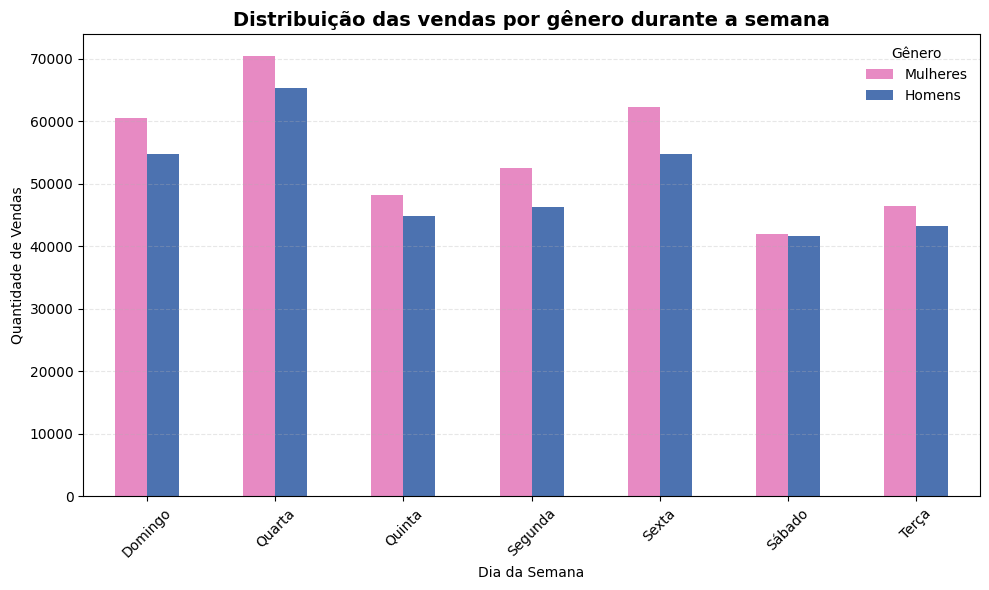

In [79]:
genero_dia.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#E78AC3", "#4C72B0"]
)

plt.title(
    "Distribuição das vendas por gênero durante a semana",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Dia da Semana")
plt.ylabel("Quantidade de Vendas")

plt.xticks(rotation=45)

plt.legend(
    ["Mulheres", "Homens"],
    title="Gênero",
    frameon=False
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Aparentemente os dias que mais vendem são quartas, sextas e domingos.
A quantidade de compras feitas por mulheres são maiores em todos os dias.
O dia em que os homens mais compram são na quarta feira.
Criar promoções nesses dias podem aumentar as vendas da loja. Caso o objetivo seja atingir o público masculino o ideal é que essas ações sejam feitas nas quartas feiras.

## Análise 2

Agora vamos avaliar as compras agrupadas por segmentação econômica.

O objetivo é verificar se existe uma classe econômica que nós atingimos mais. Se alguma classe compra mais que as outras e o volume de itens por compra.

Teremos que analisar os IDs de cada cliente, os IDs das compras e contar a quantidade de compras realizadas por cada um.
Depois vamos precisar da média de itens comprados no mesmo id de compra e verificar quantas compras foram feitas para cada cliente.

In [75]:
analise_segmento = (
    df.groupby("CL_SEG")
      .agg(
          clientes=("CL_ID", "nunique"),
          compras=("CO_ID", "nunique"),
          itens=("CO_ID", "count")
      )
)

analise_segmento["Itens por compra"] = (
    analise_segmento["itens"] / analise_segmento["compras"]
).round(2)

analise_segmento["Compras por cliente"] = (
    analise_segmento["compras"] / analise_segmento["clientes"]
).round(2)

print(analise_segmento)

        clientes  compras   itens  Itens por compra  Compras por cliente
CL_SEG                                                                  
A             84     1492   59677             40.00                17.76
B            645    11843  468505             39.56                18.36
C            271     5136  205265             39.97                18.95


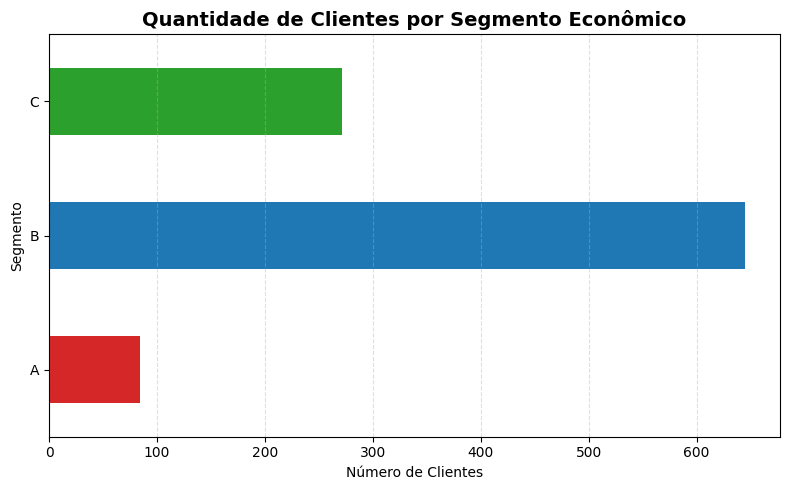

In [78]:
clientes = analise_segmento["clientes"]

plt.figure(figsize=(8,5))

ax = clientes.plot(
    kind="barh",
    color=["#d62728", "#1f77b4", "#2ca02c"]
)

plt.title(
    "Quantidade de Clientes por Segmento Econômico",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Número de Clientes")
plt.ylabel("Segmento")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

A classe que mais frequenta a loja é a B.

A média de produtos comprados por cada categoria é semelhante.

A falta de uma coluna com valores impede a avaliação de qual das classes mais gasta.

Seria interessante pensar em formas de atrair o público da classe A, já que é a que faz menos compras.